In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

df = pd.read_csv('owid-covid-data.csv')
print(df.shape)
print(df.head())

(44785, 41)
  iso_code continent     location        date  total_cases  new_cases  \
0      AFG      Asia  Afghanistan  2019-12-31          0.0        0.0   
1      AFG      Asia  Afghanistan  2020-01-01          0.0        0.0   
2      AFG      Asia  Afghanistan  2020-01-02          0.0        0.0   
3      AFG      Asia  Afghanistan  2020-01-03          0.0        0.0   
4      AFG      Asia  Afghanistan  2020-01-04          0.0        0.0   

   new_cases_smoothed  total_deaths  new_deaths  new_deaths_smoothed  ...  \
0                 NaN           0.0         0.0                  NaN  ...   
1                 NaN           0.0         0.0                  NaN  ...   
2                 NaN           0.0         0.0                  NaN  ...   
3                 NaN           0.0         0.0                  NaN  ...   
4                 NaN           0.0         0.0                  NaN  ...   

   gdp_per_capita  extreme_poverty  cardiovasc_death_rate  \
0        1803.987        

In [21]:
print(df['location'].nunique())
print(df['location'].unique()[:20])
print(df.isnull().sum().head(10))

212
<StringArray>
[        'Afghanistan',             'Albania',             'Algeria',
             'Andorra',              'Angola',            'Anguilla',
 'Antigua and Barbuda',           'Argentina',             'Armenia',
               'Aruba',           'Australia',             'Austria',
          'Azerbaijan',             'Bahamas',             'Bahrain',
          'Bangladesh',            'Barbados',             'Belarus',
             'Belgium',              'Belize']
Length: 20, dtype: str
iso_code                264
continent               528
location                  0
date                      0
total_cases             603
new_cases               803
new_cases_smoothed     1585
total_deaths            603
new_deaths              803
new_deaths_smoothed    1585
dtype: int64


In [22]:
countries = ['India', 'United States', 'United Kingdom', 'Brazil', 'Russia']
df_countries = df[df['location'].isin(countries)]
print(df_countries['location'].value_counts())

location
Brazil            264
India             264
Russia            264
United Kingdom    264
United States     264
Name: count, dtype: int64


location
World            30540446.0
United States     6724667.0
India             5308014.0
Brazil            4495183.0
Russia            1091186.0
Peru               756412.0
Colombia           750471.0
Mexico             688954.0
South Africa       657627.0
Spain              640040.0
Name: total_cases, dtype: float64


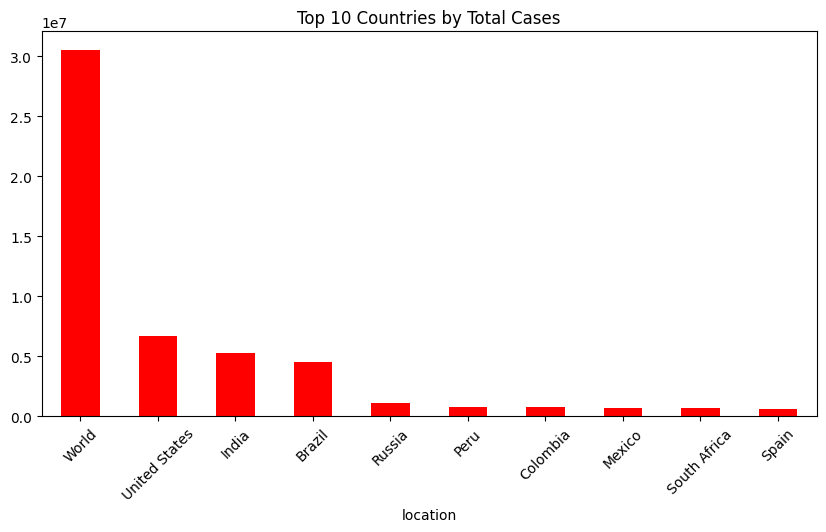

In [23]:
latest = df.groupby('location')['total_cases'].max().sort_values(ascending=False).head(10)
print(latest)
latest.plot(kind='bar', title='Top 10 Countries by Total Cases', color='red', figsize=(10,5))
plt.xticks(rotation=45)
plt.show()


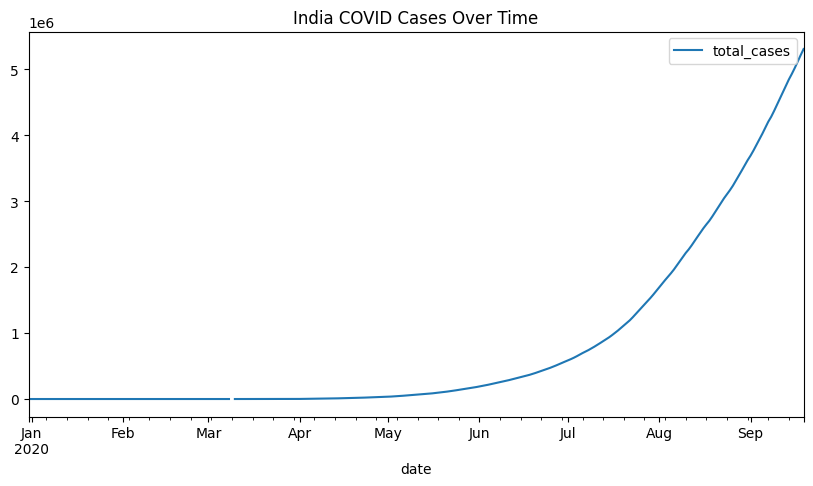

In [24]:
india = df[df['location']=='India']
india['date'] = pd.to_datetime(india['date'])
india.plot(x='date', y='total_cases', title='India COVID Cases Over Time', figsize=(10,5))
plt.show()

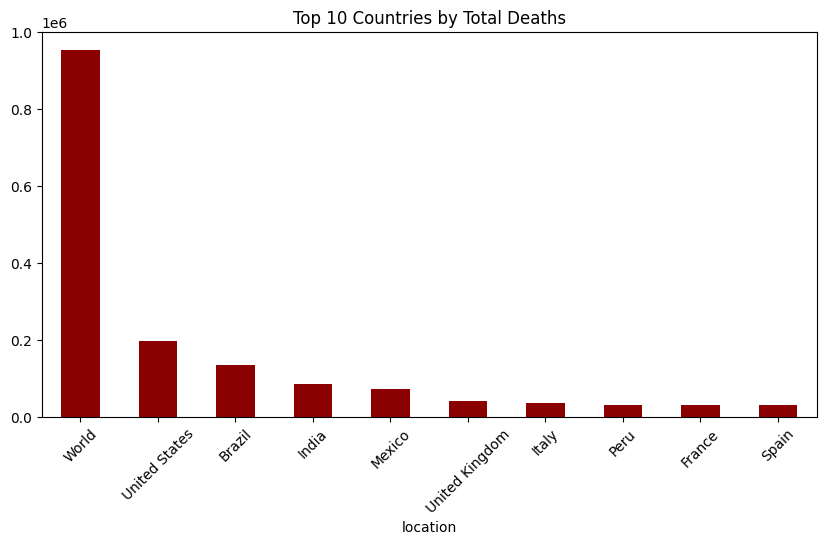

In [25]:
death_rate = df.groupby('location')['total_deaths'].max().sort_values(ascending=False).head(10)
death_rate.plot(kind='bar', title='Top 10 Countries by Total Deaths', color='darkred', figsize=(10,5))
plt.xticks(rotation=45)
plt.show()

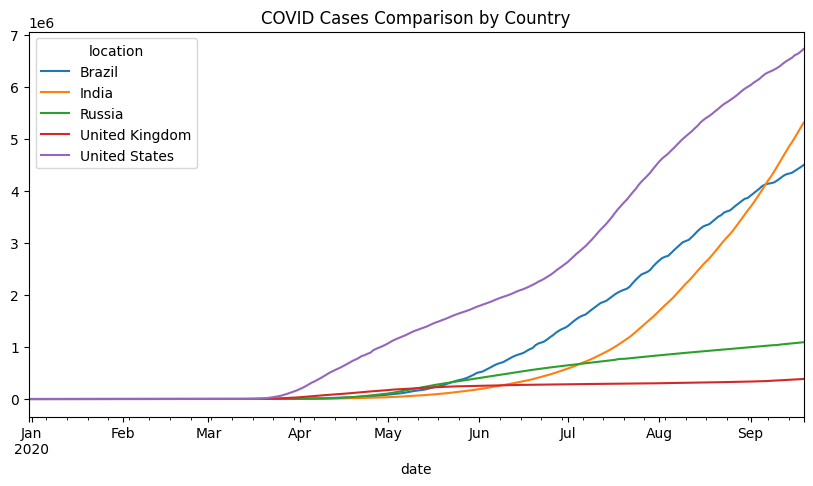

In [26]:
df_countries['date'] = pd.to_datetime(df_countries['date'])
pivot = df_countries.groupby(['date','location'])['total_cases'].max().unstack()
pivot.plot(figsize=(10,5), title='COVID Cases Comparison by Country')
plt.show()

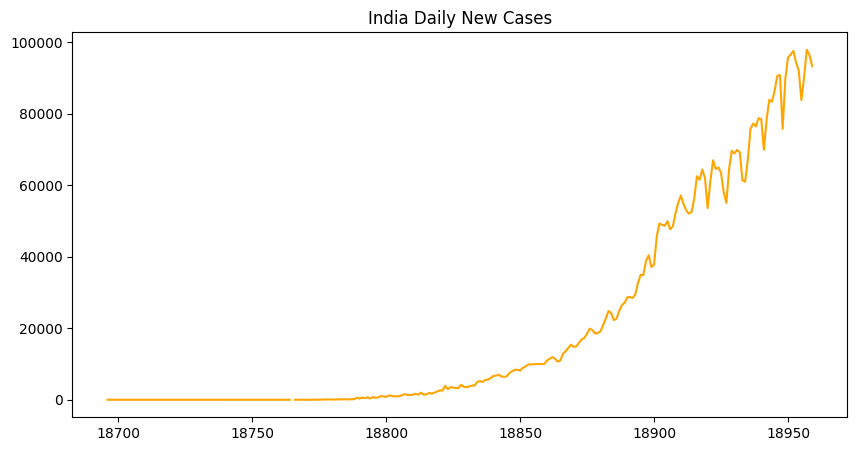

In [27]:
india['new_cases'].plot(figsize=(10,5), title='India Daily New Cases', color='orange')
plt.show()

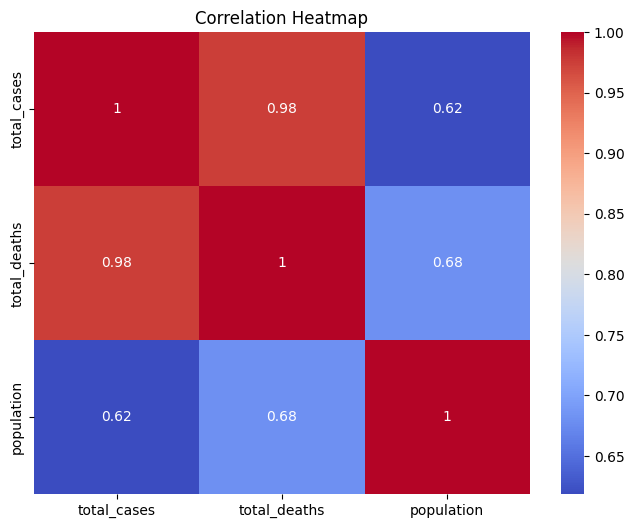

In [28]:
cols = ['total_cases','total_deaths','population']
df_corr = df[cols].dropna()
corr = df_corr.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

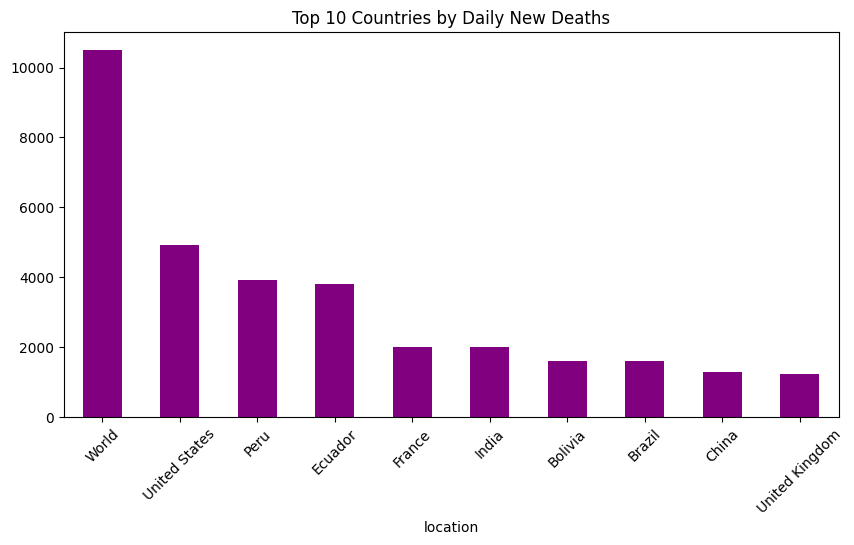

In [34]:
new_deaths = df.groupby('location')['new_deaths'].max().dropna().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
new_deaths.plot(kind='bar', title='Top 10 Countries by Daily New Deaths', color='purple')
plt.xticks(rotation=45)
plt.show()